3) Il mercato sta subendo una mutazione nel tempo? Il trend storico dimostra un'inflazione dei voti?

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_pickle('10KAnime.pickle')

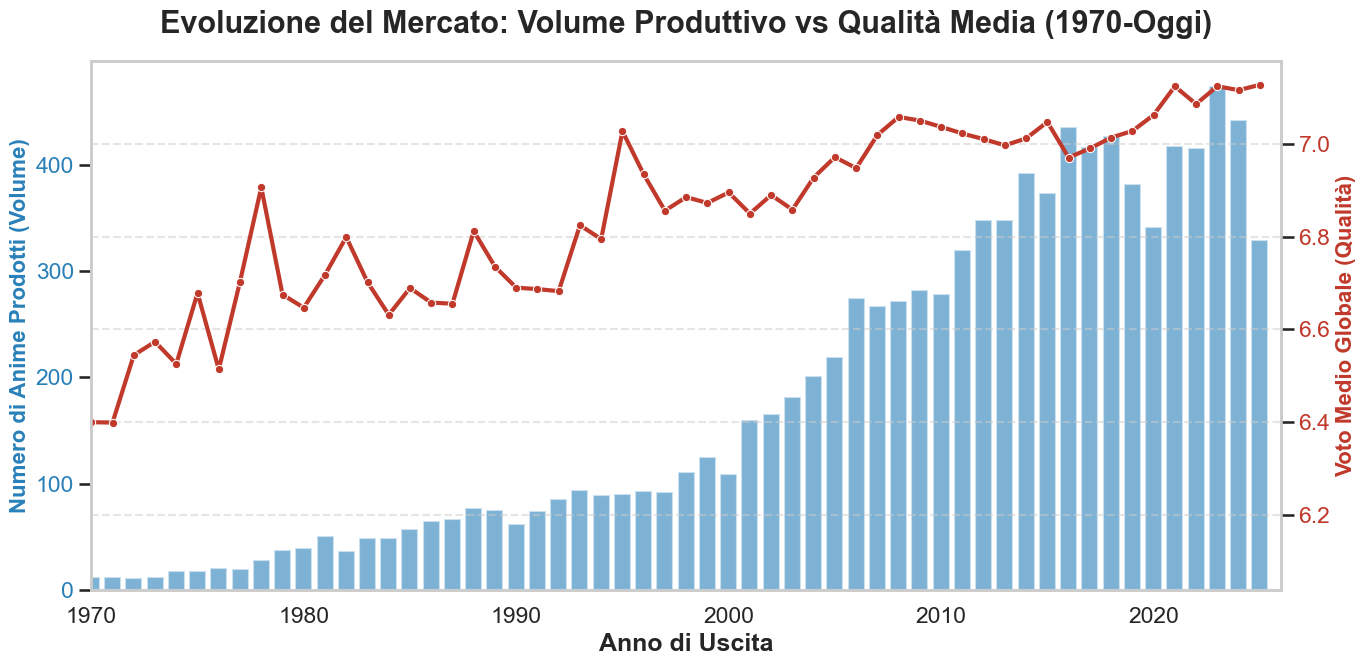

In [4]:
#preparazione dei dati: calcolo quanti anime e il voto medio per ogni anno
df_storico = df.groupby('year').agg(
    anime_prodotti=('score', 'count'),
    voto_medio=('score', 'mean')
).reset_index()

#creo la figura
sns.set_theme(style='whitegrid', context="talk")
fig, ax1 = plt.subplots(figsize=(14, 7))

#primo asse(sx): il volume produttivo a barre
ax1.bar(df_storico['year'], df_storico['anime_prodotti'], 
        color='#2980b9', alpha=0.6)

ax1.set_xlabel('Anno di Uscita', weight='bold', fontsize=18)
ax1.set_ylabel('Numero di Anime Prodotti (Volume)', weight='bold', color='#2980b9', fontsize=16)
ax1.tick_params(axis='y', labelcolor='#2980b9') #coloro i numeri dell'asse Y

#secondo asse(dx): il voto medio per anno
ax2 = ax1.twinx() # twinx "clona" l'asse X ma crea un asse Y indipendente a destra
sns.lineplot(data=df_storico, x='year', y='voto_medio', 
             ax=ax2, color='#c0392b', linewidth=3, marker='o', markersize=6)

ax2.set_ylabel('Voto Medio Globale (Qualità)', weight='bold', color='#c0392b', fontsize=16)
ax2.tick_params(axis='y', labelcolor='#c0392b')

#ottimizzazione e titolo
plt.title('Evoluzione del Mercato: Volume Produttivo vs Qualità Media (1970-Oggi)', weight='bold', pad=20, fontsize=22)
plt.xlim(1970, df_storico['year'].max() + 1) # Blocchiamo l'asse X dal 1970 a oggi

#griglia 
ax1.grid(False)
ax2.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()

#salvataggio
plt.savefig("Figures/3.png", bbox_inches='tight')
plt.savefig("Figures/3.svg", bbox_inches='tight')

plt.show()